# Machine learning using nested cross validation

Final version of code to predict benign vs non-benign in all soft tissue tumours

Develops the model using retrospective data. 

Once data is important numerous different machoine model types are trained, uing nested cross-validation. The model type (e.g. logistic regression, support vector classifier etc...) that gives the best performance across all outer fold test datasets of nested cross validation is selected to be ensembled. This ensemble is the final mocel that can be used ot make predicitons on new data.

1. Import packages and load data
2. Clean data as required
3. Remove highly correlated features and those with no variance - save the lists of removed features to apply to test set later. This is done outside of nested cross-validation, it may have been better to do it inside but that was more challenging to code,
4. Nested cross validation - 5 differnet machine learning models used: Logistic Regression, Support Vector Machine, Random Forest, XGBoost and additionally a Neural Network
4a INside cross-validation select for highest AUC, but additionally calcualte a threshold that aims for 95% sensitivity
5. Look at the auc score of each across all 5 outer folds. Also keep record of thresholds with > 95% sens, and spec at those thresholds
6. Ensemble the models and pick based on performance on test folds 


## 1. Import packages and load data

### Load packages

In [1]:
# import libraries
# General
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import re
from sklearn.base import BaseEstimator, TransformerMixin

import joblib
import os

# Before training
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, roc_auc_score, make_scorer
from scipy.stats import mannwhitneyu


from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LassoCV


from sklearn.model_selection import StratifiedKFold

# Ensembling
#from sklearn.frozen import FrozenEstimator # prevent the ensemble model re-fitting, but sadly doens't work that way

# checking biases
from statsmodels.stats.proportion import proportions_ztest # Two-proportion z-test
import scipy.stats as stats # for chi square
import statsmodels.api as sm # for making a logistic regression model of age



from sklearn.base import clone


In [2]:
from joblib import Parallel, delayed

In [3]:
# Additional libraries needed for neural networks

# Ignore the yellow underlines, they do all import
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.feature_selection import SelectFromModel

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
warnings.filterwarnings("ignore")

My in-built code for doing radiomics experiments

In [36]:
import sys
sys.path.append(r"D:\Radiomics\Util_scripts")
from Custom_ML_pipelineSteps import CoefficientOfVariationFilter, CorrelationFilter
from NestedCrossVal_training import nested_training, plot_overall_AUC, mean_ci
from PreProcessing import remove_unstable, pval_and_auc

### Load data

Note - do NOT open the csv in excel or it converts a whole load of PseudoID's to numbers e.g. 1234E56789 become a huge number and it's really irritating

In [ ]:
df_file = r"D:\Radiomics\RetrospectiveData\MyVersions\radiomics_features_auto.csv"
suffix = "_auto"

df_features = pd.read_csv(df_file, dtype={'PseudoPatientID': str})
print("Feature df")
print(f"shape of input data: {df_features.shape}")
#print(df.head)
#print(df_features.columns)


print("\nLabel df")
df_labels = pd.read_csv(r"F:\PhD\Retrospective data\radiomics_clin_info_final.csv") # new file that includes anatomy
print(f"shape of input data: {df_labels.shape}")
#print(df.head)
#print(df_labels.columns)



Feature df
shape of input data: (951, 1405)

Label df
shape of input data: (951, 12)


In [14]:
df_labels['grouped_subtype'].value_counts()[0:15]

grouped_subtype
Lipoma                                      376
Benign nerve tumour                          60
liposarcoma                                  45
Pleomorphic sarcoma                          45
Vascular tumour/malformation                 39
leiomyosarcoma                               27
Benign myxoid tumour                         25
myxofibrosarcoma                             23
Desmoid fibromatosis                         22
myxoid liposarcoma                           21
Benign cyst                                  19
Inflammatory / reactive lesion               17
Tenosynovial giant cell tumour               17
Neurofibroma / NF-related                    14
Malignant peripheral nerve sheath tumour     14
Name: count, dtype: int64

In [7]:
# Look at most common benign and non-benign subtypes
# Top 15 subtypes where final_dx == 0
top0 = (df_labels.loc[df_labels['final_dx'] == 0, 'grouped_subtype']
                   .value_counts())

# Top 15 subtypes where final_dx == 1
top1 = (df_labels.loc[df_labels['final_dx'] == 1, 'grouped_subtype']
                   .value_counts())

print("Benign subtypes")
print(top0[0:5])#

print("\n")
print("Non-benign subtypes")
print(top1[0:5])

Benign subtypes
grouped_subtype
Lipoma                          376
Benign nerve tumour              60
Vascular tumour/malformation     39
Benign myxoid tumour             25
Benign cyst                      19
Name: count, dtype: int64


Non-benign subtypes
grouped_subtype
Pleomorphic sarcoma     45
liposarcoma             45
leiomyosarcoma          27
myxofibrosarcoma        23
Desmoid fibromatosis    22
Name: count, dtype: int64


In [9]:
# checking same patients appear in both the features csv and the ground truth csv
# If the legth of the 2 is not the same:

# IDs in each dataframe
feature_ids = set(df_features["PseudoPatientID"])
label_ids = set(df_labels["PseudoPatientID"])

# Find IDs only in features
extra_in_features = feature_ids - label_ids
print("IDs in features but not in labels:", extra_in_features)

IDs in features but not in labels: set()


In [10]:
extra_in_features = label_ids - feature_ids
print("IDs in labels but not in features:", extra_in_features)

IDs in labels but not in features: set()


Combine features with labels

In [15]:
df_final = pd.merge(df_features, df_labels, on="PseudoPatientID")

Determine where to save results of modelling

In [ ]:
exp_dir = os.path.join(r"D:\Radiomics\RetrospectiveData\Final_Results\Test")

## 2. Cleaning data

Check for missing data. Spoilers, there is none in the radiomics features, but some clinical info is missing

In [12]:
counter = 0

for column in df_final:
    if df_final[column].isnull().sum() > 0:  # Only process columns with missing values
        print(f"Missing data in column: \t {column}")
        counter += 1

print(f"{counter} columns with missing data")

Missing data in column: 	 BroadEthnicGroup
Missing data in column: 	 Pathology_type
2 columns with missing data


In [16]:
#df_final.columns

categorical_cols = ['BroadEthnicGroup', 'Sex', 'AgeBandAtFirstDiagnosis', 'anatomy']

# Print unique values for each
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df_final[col].unique())
    print()

Unique values in 'BroadEthnicGroup':
['White' 'Not Stated' 'Asian' 'Other' nan 'Mixed' 'Black']

Unique values in 'Sex':
['Female' 'Male']

Unique values in 'AgeBandAtFirstDiagnosis':
['25 - 29' '50 - 54' '55 - 59' '80 and over' '20 - 24' '30 - 34' '75 - 79'
 '60 - 64' '70 - 74' '45 - 49' '15 - 19' '40 - 44' '65 - 69' '35 - 39']

Unique values in 'anatomy':
["['MRI Forearm Lt']" "['MRI Upper arm Lt']" "['MRI Femur Lt']"
 "['MRI Knee Rt']" "['MRI Hip Lt']" "['MRI Shoulder Rt']" '[MRI Abdomen]'
 "['MRI Knee Lt']" "['MRI Thorax']" '[MRI Upper arm Rt]' "['MRI Abdomen']"
 "['MRI Pelvis']" "['MRI Femur Rt']" "['MRI Spine cervical']"
 "['MRI Head']" "['MRI Forearm Rt']" "['MRI Upper arm Rt']"
 '[MRI Femur Rt]' "['MRI Spine thoracic']" "['MRI Scapula Rt']"
 '[MRI Forearm Lt]' "['MRI Hand Rt']" "['MRI Groin Both']"
 "['MRI Lower Leg Lt']" "['MRI Neck']" "['MRI Hip Rt']"
 "['MRI Buttock Lt']" '[MRI Axilla Rt (sarcoma)]' '[MRI Pelvis]'
 '[MRI Lower Leg Rt]' "['MRI Lower Leg Rt']" "['MRI Fingers L

Drop clincial columns not used here

In [17]:
df = df_final.drop(columns=['BroadEthnicGroup', 'Sex', 'AgeBandAtFirstDiagnosis', 'Date', 'anatomy', 'subtype', 'Grade', 'Pathology_type', 'WHO_category', 'grouped_subtype'])

# Separate features and labels
X = df.drop(columns=['PseudoPatientID', 'final_dx'])
y = df['final_dx']

In [18]:
X.columns

Index(['T1_auto_original_shape_Elongation', 'T1_auto_original_shape_Flatness',
       'T1_auto_original_shape_LeastAxisLength',
       'T1_auto_original_shape_MajorAxisLength',
       'T1_auto_original_shape_Maximum2DDiameterColumn',
       'T1_auto_original_shape_Maximum2DDiameterRow',
       'T1_auto_original_shape_Maximum2DDiameterSlice',
       'T1_auto_original_shape_Maximum3DDiameter',
       'T1_auto_original_shape_MeshVolume',
       'T1_auto_original_shape_MinorAxisLength',
       ...
       'T2_auto_wavelet-LL_gldm_GrayLevelNonUniformity',
       'T2_auto_wavelet-LL_gldm_GrayLevelVariance',
       'T2_auto_wavelet-LL_gldm_HighGrayLevelEmphasis',
       'T2_auto_wavelet-LL_gldm_LargeDependenceEmphasis',
       'T2_auto_wavelet-LL_gldm_LargeDependenceHighGrayLevelEmphasis',
       'T2_auto_wavelet-LL_gldm_LargeDependenceLowGrayLevelEmphasis',
       'T2_auto_wavelet-LL_gldm_LowGrayLevelEmphasis',
       'T2_auto_wavelet-LL_gldm_SmallDependenceEmphasis',
       'T2_auto_wavelet-

## 3. Feature selection - remove unstable features

I have used cases which have been segmented by 2 observers. Only features with an ICC ≥ 0.9 have been kept, removing 260 features.

The features have been removed prior to train/test splitting so there is maybe a small element of overfitting here, but their predictive value etc... has not been assessed

In [19]:
print(f"Number of features: {X.shape[-1]}")

Number of features: 1404


In [20]:
filename = r"D:\Radiomics\RetrospectiveData\MyVersions\Feature_stability\excluded_features.txt"

print(f"Original number of features: {X.shape[-1]}")
X = remove_unstable(X, filename)
print(f"Filtered number of features: {X.shape[-1]}")

Original number of features: 1404
Number of excluded features: 260
Filtered number of features: 1144


## 4. Nested Cross validation

Looking at the following models - 5 folds for each:
1. Logistic regression
2. Support vector machine
3. Random forest
4. XGBoost
5. Neural network (with 100 features input)



In [ ]:
X_train = X.copy() # creating copies of dataframes in case change something later accidentally so still have original one
y_train = y.copy()

print(f"{len(X_train)} cases in X and {len(y_train)} cases in y")

951 cases in X and 951 cases in y


In [22]:
print(f"number of postiive (non-benign) cases: {y_train.sum()}")

number of postiive (non-benign) cases: 277


### Setting up pipeline steps including feature selection

removing any features with a coefficient of variation < 1% and features with pearson correlaiton coefficient > 0.9

In [23]:
# Stuff that is consistent across all - note neural network needs to be treated a little bit differently

inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



imputer = KNNImputer(n_neighbors=5, weights="uniform") 
cv_filter = CoefficientOfVariationFilter(threshold=0.01)  # from cells above
corr_filter = CorrelationFilter(threshold=0.9)
scaler = StandardScaler()
# Define LASSO for feature selection - see https://scikit-learn.org/stable/modules/feature_selection.html (1.13.4.1 L1 based feature selection - Lasso is for regression)
feature_selector = SelectFromModel(
    #LogisticRegression(penalty="l1", solver="saga", max_iter=5000, C=1.0, random_state=42)  # the smaller C the fewer features selected. 
    LogisticRegression(penalty="l1", solver="saga", max_iter=5000, random_state=42)  # the smaller C the fewer features selected. 
)


feature_selector_RF = SelectFromModel(
    estimator=LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42),
    threshold='mean'  # or '0.01' as needed
)

feature_selector_NN = SelectKBest(score_func=f_classif)

Looking at target performance

In [24]:
# Desired sensitivity
target_sensitivity = 0.95
target_sensitivity_2 = 0.98

### Logistic regression

Checking how many features kept when using different values for C and my feature selector, now removed as determined limits

In [ ]:
'''
# Scale features first (same as inside pipeline)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different C values
for c in [0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 1]:
    sel = SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            C=c,
            random_state=42
        )
    )
    sel.fit(X_scaled, y)
    print(f"C={c}: {sel.transform(X_scaled).shape[1]} features kept")
'''

Set up logistic regression pipeline with all stagea and grid to search over

In [27]:
model_name_LR = 'LR'

logreg_pipe = Pipeline([
    ('imputer', imputer),
    ('cv_filter', cv_filter),
    ('corr_filter', corr_filter),
    ('scaler', scaler),
    ('feature_selection', feature_selector),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)) # using balanced so that it doens;t favour the more prevalent class
])

# print(np.logspace(-2, -1, 5)) # checking values for C make sense

grid_LR = {
    # 0.3 still too high, get loads of features
    "feature_selection__estimator__C": np.logspace(-2, -1, 5), #[0.01, 0.03, 0.05, 0.1, 0.3], #np.logspace(-4, 1, 5),   # C for feature selector logistic regression - previously [0.01, 0.1, 1, 10]
    "classifier__C":   [0.01, 0.03, 0.1, 0.3, 1],# np.logspace(-4, 1, 10),                   # C for classifier logistic regression - used to include option for 10 too
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"] # saga used in every single fold so removing liblinear for rerun, set this back afterwards
}

In [28]:
# jsut for getting the figure below, nothing else done with this
logreg_pipe.fit(X_train, y_train)

,steps,"[('imputer', ...), ('cv_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


Size of test data: 191, (56 positive labels)
[Inner CV] Running 100 parameter combinations with 10 folds = 1000 total fits (10 jobs in parallel).
Saved model for fold 1 to D:\Radiomics\RetrospectiveData\Final_Results\Test\LR\LR_best_model_fold_1.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 100 parameter combinations with 10 folds = 1000 total fits (10 jobs in parallel).
Saved model for fold 2 to D:\Radiomics\RetrospectiveData\Final_Results\Test\LR\LR_best_model_fold_2.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 100 parameter combinations with 10 folds = 1000 total fits (10 jobs in parallel).
Saved model for fold 3 to D:\Radiomics\RetrospectiveData\Final_Results\Test\LR\LR_best_model_fold_3.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 100 parameter combinations with 10 folds = 1000 total fits (10 jobs in parallel).
Saved model for fold 4 to D:\Radiomics\RetrospectiveData\Final_Results\Test\LR\LR_best_model_fo

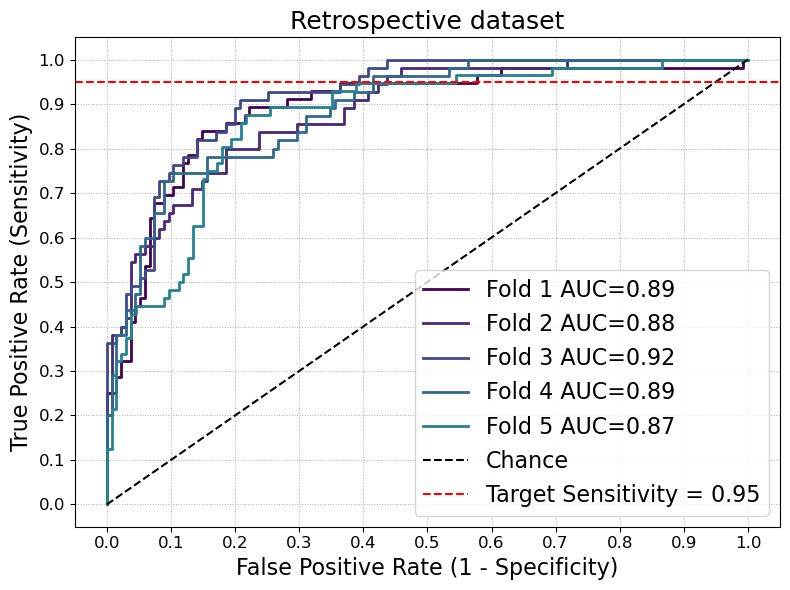

Mean ROC plot saved to D:\Radiomics\RetrospectiveData\Final_Results\Test\Results\LR_roc_mean.jpg


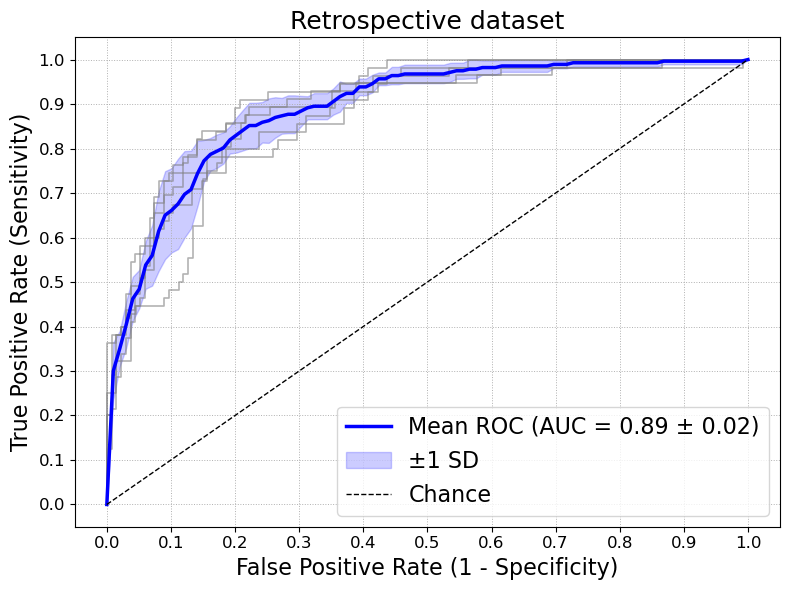

In [30]:
results_df_LR, predictions_df_LR, features_df = nested_training(X_train, y_train, logreg_pipe, grid_LR, model_name_LR, exp_dir, outer_cv, inner_cv,
                                feature_selector_in_pipe=True, random_search = False, target_sensitivity = target_sensitivity,
                                title_text="Retrospective dataset", plot_mean_roc_curve=True, return_outer_proba=True, interpret_features = True)


In [31]:
results_df_LR

,fold,feature_selection__estimator__C,classifier__C,classifier__penalty,classifier__solver,n_features_after_CoV_filter,n_features_after_corr_filter,n_features_afterFeatSelection,auc_val,youden_threshold,threshold,train_sens_at_threshold,train_spec_at_threshold,test_auc_scores,sensitivity(at_threshold),specificity(at_threshold)
0,1,0.100000,0.10,l1,saga,1133,260,29,0.890,0.4930,0.3056,0.933,0.647,0.892,0.911,0.711
1,2,0.031623,0.10,l2,saga,1132,258,12,0.899,0.4566,0.3161,0.916,0.662,0.884,0.855,0.652
2,3,0.031623,0.03,l2,saga,1133,258,13,0.881,0.5279,0.2999,0.921,0.616,0.917,0.927,0.681
3,4,0.017783,0.10,l2,saga,1133,256,9,0.889,0.5502,0.2442,0.945,0.583,0.889,0.909,0.622
4,5,0.031623,0.30,l2,saga,1133,265,11,0.903,0.4952,0.2767,0.928,0.637,0.867,0.929,0.634


In [40]:
mean_auc_LR, CI_low_LR, CI_high_LR = mean_ci(results_df_LR['test_auc_scores'])

print(f"Mean AUC across outer folds: {mean_auc_LR:.3f} [{CI_low_LR:.3f} - {CI_high_LR:.3f}]")

Mean AUC across outer folds: 0.890 [0.867 - 0.912]


In [41]:
predictions_df_LR.to_csv(os.path.join(exp_dir, model_name_LR, "predicitons.csv"))

ROC plot saved to D:\Radiomics\RetrospectiveData\Final_Results\Test\LR\Logistic regression - pooled ROC curve_pooled_ROC_allTestSets.jpg


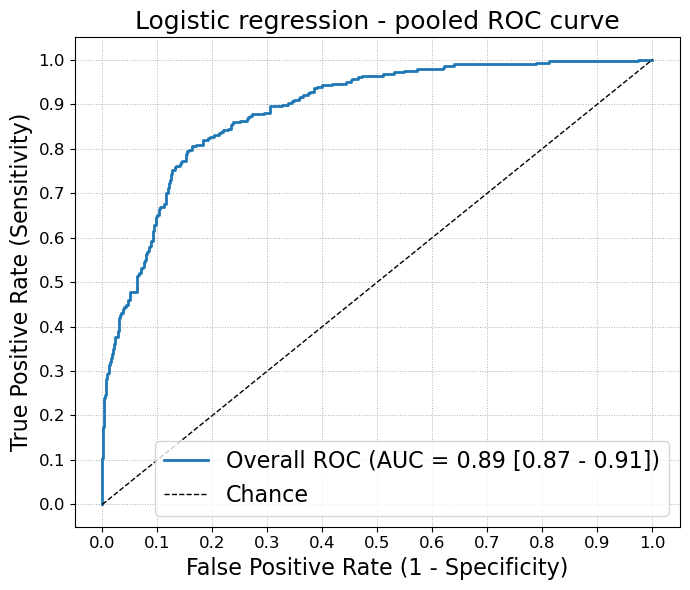

AUC:	0.89 [0.87, 0.91]


In [43]:
auc_pooled_LR, auc_LR_ci = plot_overall_AUC(predictions_df_LR['true'], predictions_df_LR['proba'], title = "Logistic regression - pooled ROC curve", save_folder=os.path.join(exp_dir, model_name_LR))
print(f"AUC:\t{auc_pooled_LR:.2f} [{auc_LR_ci[0]:.2f}, {auc_LR_ci[1]:.2f}]")


In [44]:
def plot_mean_roc_with_95sensLine(X_train, y_train, model_name, model_save_dir, outer_cv, title_text):
    """
    Plot mean ROC curve across all outer folds, showing individual fold curves in grey,
    and the mean ROC (±1 SD) in blue.
    """
    from sklearn.metrics import roc_curve, auc
    import numpy as np
    import matplotlib.pyplot as plt
    import joblib
    import os

    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    plt.figure(figsize=(8, 6))

    # Plot each individual ROC curve in grey
    for fold_number, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        X_train_cv, X_test_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_cv, y_test_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model_path = os.path.join(model_save_dir, model_name, f"{model_name}_best_model_fold_{fold_number}.joblib")
        best_model = joblib.load(model_path)

        y_proba = best_model.predict_proba(X_test_cv)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_cv, y_proba)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        plt.plot(fpr, tpr, color='grey', lw=1.2, alpha=0.6)

        # Interpolate to a common FPR grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    # Compute mean and std of the interpolated TPRs
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    # Plot mean ROC
    plt.plot(
        mean_fpr, mean_tpr, color='blue',
        label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})',
        lw=2.5
    )
    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        color='blue', alpha=0.2, label='±1 SD'
    )

    # Plot chance line
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')

    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=16)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=16)
    
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.axhline(y=0.95, color='red', linestyle='--', label='Target Sensitivity = 0.95')
    #plt.title(f'{title_text} \n Mean ROC Across Outer Folds', fontsize=16)
    plt.title(f'{title_text}', fontsize=18)
    plt.legend(loc='lower right', fontsize=16)
    plt.grid(True, which='both', linestyle=':', linewidth=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

### Support vector machine

In [45]:
SVM_pipe = Pipeline([
    ('imputer', imputer),
    ('cv_filter', cv_filter),
    ('corr_filter', corr_filter),
    ('scaler', scaler), 
    ('feature_selection', feature_selector),
    ('classifier', SVC(probability=True, random_state=42, class_weight = "balanced"))  # probability=True needed for ROC AUC
])

# Keeping grid small for time purposes
grid_SVM = {
    "feature_selection__estimator__C": np.logspace(-2, -1, 5), #np.logspace(-4, 1, 5),   # C for feature selector logistic regression - previously [0.01, 0.1, 1, 10]
    "classifier__kernel": ['linear', 'rbf'], # not exploring poly. This is deliberate - see below
    "classifier__C": [0.01, 0.03, 0.1, 0.3, 1],
    "classifier__gamma": ['scale', 0.01, 0.1]#,  # only matters if rbf, ignored for linear kernel, so this could be re-written to be more efficient
    #"classifier__class_weight": [None, 'balanced'] # only using balanced
}


model_name_SVM = "SVM"

'''
Polymnomial kernel removed as with the huge number of features i have likely to overfit
Also far more hyper-params whihc slows things down
'''

'\nPolymnomial kernel removed as with the huge number of features i have likely to overfit\nAlso far more hyper-params whihc slows things down\n'

In [ ]:
# jsut for getting the figure below, nothing else done with this
SVM_pipe.fit(X_train, y_train)

,steps,"[('imputer', ...), ('cv_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


Size of test data: 191, (56 positive labels)
[Inner CV] Running 150 parameter combinations with 10 folds = 1500 total fits (10 jobs in parallel).
Saved model for fold 1 to D:\Radiomics\RetrospectiveData\Final_Results\Test\SVM\SVM_best_model_fold_1.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 150 parameter combinations with 10 folds = 1500 total fits (10 jobs in parallel).
Saved model for fold 2 to D:\Radiomics\RetrospectiveData\Final_Results\Test\SVM\SVM_best_model_fold_2.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 150 parameter combinations with 10 folds = 1500 total fits (10 jobs in parallel).
Saved model for fold 3 to D:\Radiomics\RetrospectiveData\Final_Results\Test\SVM\SVM_best_model_fold_3.joblib
Size of test data: 190, (55 positive labels)
[Inner CV] Running 150 parameter combinations with 10 folds = 1500 total fits (10 jobs in parallel).
Saved model for fold 4 to D:\Radiomics\RetrospectiveData\Final_Results\Test\SVM\SVM_best_

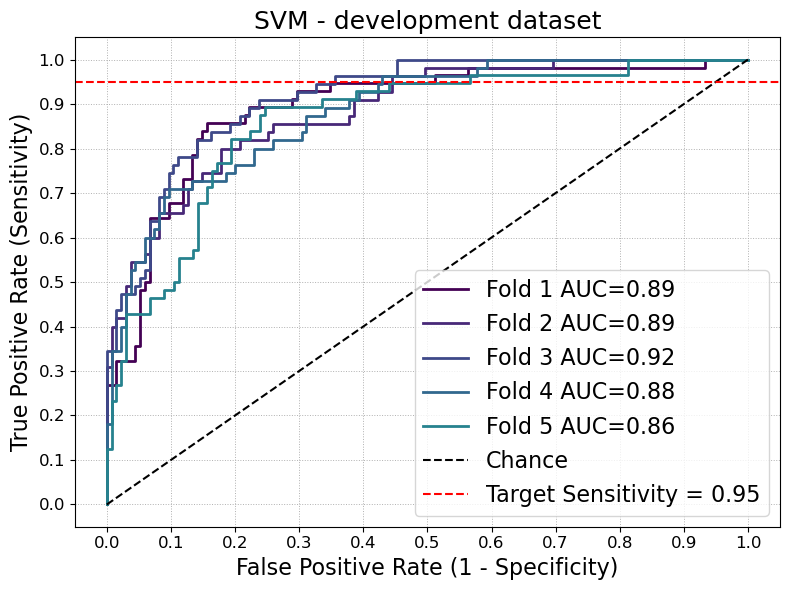

Mean ROC plot saved to D:\Radiomics\RetrospectiveData\Final_Results\Test\Results\SVM_roc_mean.jpg


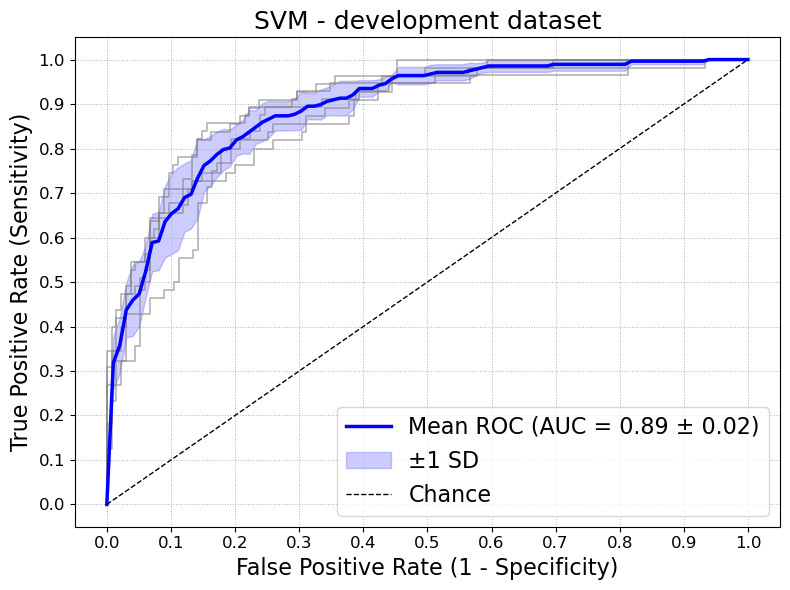

In [47]:
results_df_SVM, predictions_df_SVM, features_df = nested_training(X_train, y_train, SVM_pipe, grid_SVM, model_name_SVM, exp_dir, outer_cv, inner_cv,
                                feature_selector_in_pipe=True, random_search = False, target_sensitivity = target_sensitivity,
                                title_text="SVM - development dataset", plot_mean_roc_curve=True, return_outer_proba=True, interpret_features = True)


In [48]:
results_df_SVM

,fold,feature_selection__estimator__C,classifier__kernel,classifier__C,classifier__gamma,n_features_after_CoV_filter,n_features_after_corr_filter,n_features_afterFeatSelection,auc_val,youden_threshold,threshold,train_sens_at_threshold,train_spec_at_threshold,test_auc_scores,sensitivity(at_threshold),specificity(at_threshold)
0,1,0.100000,linear,0.30,scale,1133,260,29,0.892,0.2880,0.1597,0.946,0.659,0.893,0.893,0.711
1,2,0.031623,linear,0.10,scale,1132,258,12,0.899,0.3097,0.1752,0.914,0.668,0.886,0.855,0.667
2,3,0.031623,linear,0.03,scale,1133,258,13,0.880,0.3584,0.1380,0.926,0.593,0.916,0.927,0.689
3,4,0.017783,linear,0.03,scale,1133,256,9,0.889,0.3528,0.1141,0.944,0.567,0.884,0.891,0.622
4,5,0.031623,linear,0.30,scale,1133,265,11,0.905,0.3297,0.1564,0.925,0.641,0.863,0.929,0.604


In [49]:
predictions_df_SVM.to_csv(os.path.join(exp_dir,model_name_SVM, "predicitons.csv"))



ROC plot saved to D:\Radiomics\RetrospectiveData\Final_Results\Test\SVM\Pooled ROC - SVM_pooled_ROC_allTestSets.jpg


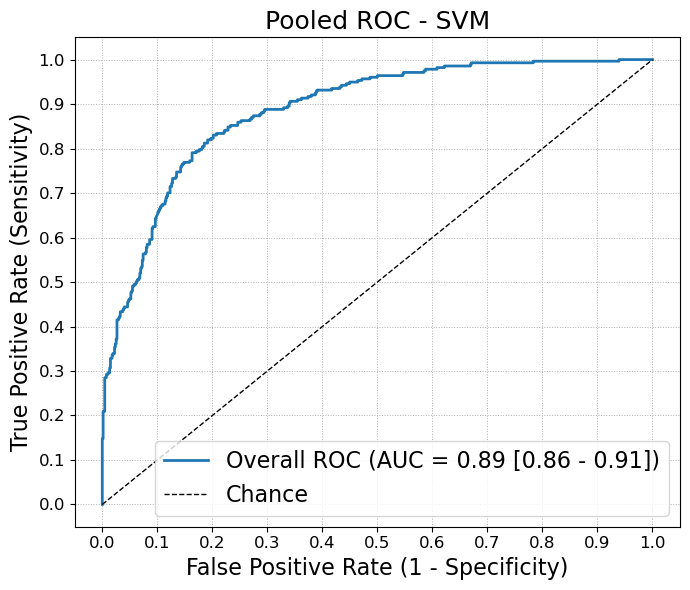

In [50]:
auc_pooled_SVM = plot_overall_AUC(predictions_df_SVM['true'], predictions_df_SVM['proba'], title = "Pooled ROC - SVM", save_folder= os.path.join(exp_dir,model_name_SVM))


### Random Forest

In [51]:
RF_pipe = Pipeline([
    ('imputer', imputer),
    ('cv_filter', cv_filter),
    ('corr_filter', corr_filter),
    #('scaler', scaler), Scaline not needed for RF as dcision tree based
    ('feature_selection', feature_selector_RF),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Keeping grid small for time purposes
grid_RF = {
    "feature_selection__estimator__C": np.logspace(-2, -1, 5), #[0.01, 0.03, 0.05, 0.1, 0.3], #np.logspace(-4, 1, 5),   # C for feature selector logistic regression - previously [0.01, 0.1, 1, 10]
    "classifier__n_estimators": [50, 100, 150, 200, 250], # number of decision trees, default was 10, now increased to 100, more generally better but reaches plateau and takes longer
    "classifier__max_depth": [None, 5, 10], # How deep each tree can go
    "classifier__min_samples_split": [2, 5], #Minimum number of samples required to split a node, higher values keep simpler and may prevent over fitting
    "classifier__min_samples_leaf": [1, 2], # I'm not sure I understand how this is different, it's the minimum number that can be in a leaf
    "classifier__max_features": ['sqrt', 'log2'], # Number of features that can be considered in a split. Lower values → more diversity between trees → better generalisation.
    "classifier__criterion": ["gini", "log_loss"] # could also use entropy as well but for now jsut sticking with gini and log_loss - entropy very similar to gini apparently
}

model_name_RF = 'RF'

In [52]:
# jsut for getting the figure below, nothing else done with this
RF_pipe.fit(X_train, y_train)

,steps,"[('imputer', ...), ('cv_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
results_df_RF, predictions_df_RF, features_df_RF = nested_training(X_train, y_train, RF_pipe, grid_RF, model_name_RF, exp_dir, outer_cv, inner_cv,
                                feature_selector_in_pipe=True, random_search = True, target_sensitivity = target_sensitivity,
                                title_text="Random Forest - development dataset", plot_mean_roc_curve=True, return_outer_proba=True, interpret_features = True)


In [ ]:
results_df_RF

In [ ]:
predictions_df_RF.to_csv(os.path.join(exp_dir, model_name_RF, "predicitons.csv"))

In [ ]:
auc_pooled_RF = plot_overall_AUC(predictions_df_RF['true'], predictions_df_RF['proba'], title = "Pooled ROC - RF", save_folder=os.path.join(exp_dir, model_name_RF))

### XGBoost

In [53]:
num_positive = np.sum(y_train)
num_negative = len(y_train) - num_positive

class_weight_ratio = (num_negative / num_positive)
print(class_weight_ratio) # this is recommended as the scale_pos_weight in the documetnaiton https://xgboost.readthedocs.io/en/stable/parameter.html

2.4332129963898916


In [54]:
XGB_pipe = Pipeline([
    ('imputer', imputer),
    ('cv_filter', cv_filter),
    ('corr_filter', corr_filter),
    ('feature_selection', feature_selector_RF),
    ('classifier', XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',  # or 'auc' if more appropriate
    objective='binary:logistic',  # likely for binary classification
    scale_pos_weight=class_weight_ratio,
    random_state=42
))
])



# Using random grid
grid_XGB = {
    "feature_selection__estimator__C": np.logspace(-2, -1, 5), #np.logspace(-4, 1, 5),   # C for feature selector logistic regression - previously [0.01, 0.1, 1, 10]
    "classifier__n_estimators": [50, 100, 150, 200, 250],                # number of trees
    "classifier__max_depth": [3, 5, 10],                   # tree depth
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],         # step size shrinkage
    "classifier__subsample": [0.7, 1],                      # row sampling ratio
    "classifier__colsample_bytree": [0.7, 1],               # feature sampling ratio
    "classifier__gamma": [0, 0.1, 0.3],                     # min loss reduction to make a split
    "classifier__scale_pos_weight": [class_weight_ratio] # usually fixed based on imbalance, not tuned here and set in the clasifier set up but keeping so it's stored in my output csvs
}

model_name_XGB = "XGB"

In [55]:
# jsut for getting the figure below, nothing else done with this
XGB_pipe.fit(X_train, y_train)

,steps,"[('imputer', ...), ('cv_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
results_df_XGB, predictions_df_XGB, features_df_XGB = nested_training(X_train, y_train, XGB_pipe, grid_XGB, model_name_XGB, exp_dir, outer_cv, inner_cv,
                                feature_selector_in_pipe=True, random_search = True, target_sensitivity = target_sensitivity,
                                title_text="XGBoost - development dataset", plot_mean_roc_curve=True, return_outer_proba=True, interpret_features = True)

In [ ]:
predictions_df_XGB.to_csv(os.path.join(exp_dir, model_name_XGB, "predicitons.csv"))

In [ ]:
auc_pooled_XGB = plot_overall_AUC(predictions_df_XGB['true'], predictions_df_XGB['proba'], title = "Pooled ROC - XGB", save_folder=os.path.join(exp_dir, model_name_XGB)


In [ ]:
results_df_XGB

### Neural network 

Define network

In [56]:
n_features = 20

feature_selector_NN = SelectKBest(score_func=f_classif, k = n_features) 


def create_model(input_shape = n_features, dropout_rate=0.5, learning_rate=0.001, optimizer='adam',
                 activation='relu', hidden_layer_sizes=(64, 32), l2_reg=0.01, **kwargs):
    
    #input_shape= FS.k
    if input_shape is None:
        raise ValueError("input_shape must be provided")
    
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    for units in hidden_layer_sizes:
        model.add(Dense(units, activation=activation,
                        kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    opt = tf.keras.optimizers.get(optimizer)
    opt.learning_rate = learning_rate

    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['AUC'])
    return model

'''
class KerasNNClassifier(KerasClassifier):
    def __init__(self, model, **model_kwargs):
        super().__init__(model=model, **model_kwargs)
        self.model_kwargs = model_kwargs  # store all hyperparameters

    def fit(self, X, y, **kwargs):
        # Dynamically set input_shape based on X after feature selection
        print(X.shape[1])
        self.model_ = create_model(input_shape=X.shape[1], **self.model_kwargs)
        return super().fit(X, y, **kwargs)
'''

grid_NN = {
    #'feature_selection__k': [4, 6, 8, 10, 15, 20, 30],#, 60, 80],
    'classifier__batch_size': [10, 20, 40, 60],
    'classifier__epochs': [50, 100],
    'classifier__model__learning_rate': [0.001, 0.003, 0.01, 0.03, 0.1],
    'classifier__model__dropout_rate': [0.2, 0.4, 0.5],
    'classifier__model__optimizer': ['adam', 'sgd'],
    'classifier__model__activation': ['relu', 'tanh'],
    'classifier__model__hidden_layer_sizes': [(64, 32), (128, 64), (100,), (100, 50, 25)],
    'classifier__model__l2_reg': [0.0, 0.001, 0.01, 0.1], 
}

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

NN_pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('cv_filter', cv_filter),
    ('corr_filter', corr_filter),
    ('scaler', StandardScaler()),
    ('feature_selection', feature_selector_NN),
    ('classifier', KerasClassifier(
        model=create_model,
        verbose=0,
        validation_split=0.1,
        callbacks=[early_stop],
    ))
])

model_name_NN = f"NN_{n_features}Features"


In [57]:
# jsut for getting the figure below, nothing else done with this
NN_pipe.fit(X_train, y_train)

,steps,"[('imputer', ...), ('cv_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
results_df_NN, predictions_df_NN, features_df_NN = nested_training(X_train, y_train, NN_pipe, grid_NN, model_name_NN, exp_dir, outer_cv, inner_cv,
                                feature_selector_in_pipe=True, random_search = True, target_sensitivity = target_sensitivity,
                                title_text="Neural network - development dataset", plot_mean_roc_curve=True, return_outer_proba=True, interpret_features = True)



In [ ]:
auc_pooled_NN = plot_overall_AUC(predictions_df_NN['true'], predictions_df_NN['proba'], title = f"Pooled ROC - {model_name_NN}", save_folder= os.path.join(exp_dir, model_name_NN))

In [ ]:
predictions_df_NN.to_csv(os.path.join(exp_dir, model_name_NN, "predicitons.csv"))

## 6a Comparing results

In [ ]:
# Load results back in from file if needed

# Define the directory where the results were saved
model_save_dir = os.path.join(exp_dir, "Results")


# Load each results DataFrame
results_df_LR = pd.read_csv(os.path.join(model_save_dir, 'LR_results.csv'))
results_df_SVM = pd.read_csv(os.path.join(model_save_dir, 'SVM_results.csv'))
results_df_RF = pd.read_csv(os.path.join(model_save_dir, 'RF_results.csv'))
results_df_XGB = pd.read_csv(os.path.join(model_save_dir, 'XGB_results.csv'))
results_df_NN = pd.read_csv(os.path.join(model_save_dir, 'NN_results.csv'))

nested_scores_LR = results_df_LR["test_auc_scores"].tolist()
nested_scores_SVM = results_df_SVM["test_auc_scores"].tolist()
nested_scores_RF = results_df_RF["test_auc_scores"].tolist()
nested_scores_XGB = results_df_XGB["test_auc_scores"].tolist()
nested_scores_NN = results_df_NN["test_auc_scores"].tolist()



In [ ]:

# Define model names and their corresponding scores
model_names = ["LR", "SVM", "RF", "XGB", "NN"]

auc_df = pd.DataFrame({
    "Logistic Regression": nested_scores_LR,
    "SVM": nested_scores_SVM,
    "Random Forest": nested_scores_RF,
    "XGBoost": nested_scores_XGB,
    "Neural Network": nested_scores_NN
}).T  # Transpose so models are rows, folds are columns

auc_df.columns = [f"Fold {i+1}" for i in range(auc_df.shape[1])]
auc_df["Mean"] = auc_df.mean(axis=1)
auc_df["SD"] = auc_df.std(axis=1)




In [ ]:
# For Word (plain table to copy-paste)
print("AUC Table:")
print(auc_df.round(3).to_string())
auc_save_path = os.path.join(model_save_dir, "AUC_scores_by_model_and_fold.csv")
auc_df.round(3).to_csv(auc_save_path)


In [ ]:
print(auc_save_path)

## 6b Ensemble best model

In this section we look at which classifier has the best overall score and then ensemble the models from 5 folds, and take this as our final model.

Look at this for ensembling: https://stackoverflow.com/questions/42920148/using-sklearn-voting-ensemble-with-partial-fit

Will actually ensemble all 5 so can compare easily later on

In [ ]:
mean_scores = {
    'LR': np.mean(nested_scores_LR),
    'SVM': np.mean(nested_scores_SVM),
    'RF': np.mean(nested_scores_RF),
    'XGB': np.mean(nested_scores_XGB),
    'NN': np.mean(nested_scores_NN)
}

std_dev_scores = {
    'LR': np.std(nested_scores_LR),
    'SVM': np.std(nested_scores_SVM),
    'RF': np.std(nested_scores_RF),
    'XGB': np.std(nested_scores_XGB),
    'NN': np.std(nested_scores_NN)

}

best_model_name = max(mean_scores, key=mean_scores.get)
print(f"Best model: {best_model_name} with mean ROC-AUC: {mean_scores[best_model_name]:.3f} +/- {std_dev_scores[best_model_name]:.3f}")

In [58]:
from mlxtend.classifier import EnsembleVoteClassifier

In [ ]:
model_names = ['LR', 'SVM', 'RF', 'XGB', 'NN']


base_path = exp_dir
n_folds = outer_cv.n_splits

for m in model_names:
    model_dir = os.path.join(base_path, m)

    best_models = []
    for fold_number in range(1, n_folds + 1):
        model_path = os.path.join(model_dir, f"{m}_best_model_fold_{int(fold_number)}.joblib")
        model = joblib.load(model_path)
        best_models.append(model)

    print(f"Loaded {len(best_models)} models for {m}")


    if m == 'LR':
        model_results = results_df_LR
    elif m == 'SVM':
        model_results = results_df_SVM
    elif m == 'RF':
        model_results = results_df_RF
    elif m == 'XGB':
        model_results = results_df_XGB
    elif m == 'NN':
        model_results = results_df_NN


    threshold_to_use = model_results['threshold'].mean()

    #print(model_results['threshold'])
    print(f"threshold to use with model {m} is \t {threshold_to_use}")

    eclf = EnsembleVoteClassifier(clfs=[best_models[0], best_models[1], best_models[2], best_models[3], best_models[4]], voting = "soft", fit_base_estimators=False, weights = [1,1,1,1,1])
    eclf.fit(X, y) # doens;t actually change model, but need to fit to use it tot prediuct later

    final_model_path = os.path.join(exp_dir, "Final_ensemble")
    os.makedirs(final_model_path, exist_ok=True)


    joblib.dump(eclf, os.path.join(final_model_path, m + "_ensemble_model.joblib"))

    print(f"Saved final model to \t{final_model_path}")
    

    

## This is old code I don't think is used anymore

Too scared to delete incase it's important but I don;t think so

It helps if you want to just test e.g. ensembling the log reg model if you haven't trained all the others. However block above will ensemble and save ensemble models for each type of classifier without the below

In [59]:
best_model_name = 'LR'

In [60]:
base_path = exp_dir

model_dir = os.path.join(base_path, best_model_name)


n_folds = outer_cv.n_splits

print(n_folds)
print(model_dir)




best_models = []
for fold_number in range(1, n_folds + 1):
    model_path = os.path.join(model_dir, f"{best_model_name}_best_model_fold_{int(fold_number)}.joblib")
    model = joblib.load(model_path)
    best_models.append(model)

print(f"Loaded {len(best_models)} models for {best_model_name}")

5
D:\Radiomics\RetrospectiveData\Final_Results\Test\LR
Loaded 5 models for LR


Just a note on the above - if running the NN version, keras doesn;t play nicely with joblib necessarily. For it to work you need to also run the cell containing the create_model() function - otherwise nothing will load. This is at the bottom of section 5. I need to optimise this to save thme as keras models instead of 

#### calculate optimal threshold

In [62]:
if best_model_name == 'LR':
    model_results = results_df_LR
elif best_model_name == 'SVM':
    model_results = results_df_SVM
elif best_model_name == 'RF':
    model_results = results_df_RF
elif best_model_name == 'XGB':
    model_results = results_df_XGB
elif best_model_name == 'NN':
    model_results = results_df_NN

print(model_results.shape)

(5, 16)


In [63]:
model_results.columns

Index(['fold', 'feature_selection__estimator__C', 'classifier__C',
       'classifier__penalty', 'classifier__solver',
       'n_features_after_CoV_filter', 'n_features_after_corr_filter',
       'n_features_afterFeatSelection', 'auc_val', 'youden_threshold',
       'threshold', 'train_sens_at_threshold', 'train_spec_at_threshold',
       'test_auc_scores', 'sensitivity(at_threshold)',
       'specificity(at_threshold)'],
      dtype='object')

In [ ]:
threshold_to_use = model_results['threshold'].mean()

print(model_results['threshold'])
print(f"Threshold to use: {threshold_to_use}")

0    0.3056
1    0.3161
2    0.2999
3    0.2442
4    0.2767
Name: threshold, dtype: float64
0.2885


In [65]:
eclf = EnsembleVoteClassifier(clfs=[best_models[0], best_models[1], best_models[2], best_models[3], best_models[4]], voting = "soft", fit_base_estimators=False, weights = [1,1,1,1,1])

In [66]:
eclf

,clfs,"[Pipeline(step...ver='saga'))]), Pipeline(step...ver='saga'))]), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,verbose,0
,use_clones,True
,fit_base_estimators,False
,pipeline-1,Pipeline(step...ver='saga'))])
,pipeline-2,Pipeline(step...ver='saga'))])
,pipeline-3,Pipeline(step...ver='saga'))])
,pipeline-4,Pipeline(step...ver='saga'))])
,pipeline-5,Pipeline(step...ver='saga'))])


In [67]:
eclf.fit(X, y) # Need to do this to use for things like predictions, but base models aren't actually changed 
# You must still call .fit(X, y) to let EnsembleVoteClassifier set up internal attributes (like number of classes, etc.), but it won't touch your base models.
# Can do just a subset (e.g. X.head(50) and y.head(50)) but must make sure all values of y are included (i.e. both benign and malignant cases)

# See comment from Akanni on first answer here: https://stackoverflow.com/questions/42920148/using-sklearn-voting-ensemble-with-partial-fit (reply to question from Matthew)
# Some more manual objects later on too

,clfs,"[Pipeline(step...ver='saga'))]), Pipeline(step...ver='saga'))]), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,verbose,0
,use_clones,False
,fit_base_estimators,False
,pipeline-1,Pipeline(step...ver='saga'))])
,pipeline-2,Pipeline(step...ver='saga'))])
,pipeline-3,Pipeline(step...ver='saga'))])
,pipeline-4,Pipeline(step...ver='saga'))])
,pipeline-5,Pipeline(step...ver='saga'))])


In [69]:
# followng on from above - see below:

X_dummy = np.zeros((2, X.shape[1]))      # shape: (2, n_features)
y_dummy = [0, 1]                         # one benign, one malignant

eclf.fit(X_dummy, y_dummy)              # This will succeed

# still gives same results in following cell

,clfs,"[Pipeline(step...ver='saga'))]), Pipeline(step...ver='saga'))]), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,verbose,0
,use_clones,False
,fit_base_estimators,False
,pipeline-1,Pipeline(step...ver='saga'))])
,pipeline-2,Pipeline(step...ver='saga'))])
,pipeline-3,Pipeline(step...ver='saga'))])
,pipeline-4,Pipeline(step...ver='saga'))])
,pipeline-5,Pipeline(step...ver='saga'))])


In [70]:
# Jsut testing these models will predict things
testing_this_works = X.head(10)
print(testing_this_works.shape)


print(eclf.predict(testing_this_works))
print(eclf.predict_proba(testing_this_works))

print(y.head(10))

(10, 1144)
[0 1 1 1 1 0 1 0 0 1]
[[0.82557369 0.17442631]
 [0.16605173 0.83394827]
 [0.32360033 0.67639967]
 [0.1552856  0.8447144 ]
 [0.17751772 0.82248228]
 [0.88892588 0.11107412]
 [0.11123933 0.88876067]
 [0.96397283 0.03602717]
 [0.69621443 0.30378557]
 [0.23232982 0.76767018]]
0    0
1    0
2    0
3    1
4    0
5    0
6    1
7    0
8    0
9    1
Name: final_dx, dtype: int64


In [71]:
final_model_path = os.path.join(exp_dir, "Final_ensemble")
os.makedirs(final_model_path, exist_ok=True)


joblib.dump(eclf, os.path.join(final_model_path,best_model_name + "_ensemble_model.joblib"))

print(f"Saved final model to \t{final_model_path}")

Saved final model to 	D:\Radiomics\RetrospectiveData\Final_Results\Test\Final_ensemble


In [83]:
# To load:

# Load the ensemble
eclf_loaded = joblib.load(os.path.join(final_model_path, best_model_name + "_ensemble_model.joblib"))

# Predict on new data
#y_proba = eclf_loaded.predict_proba(X_test)  # or .predict()

## Extra - Looking at features selected in best model

A bit of exploration of features selected by model on this training dataset

In [72]:
feature_names = np.array(X.columns)
selected_features = set()

for i, model in enumerate(eclf.clfs_):
    pipe = model
    
    # Re-run imputer
    X_step1 = pipe.named_steps['imputer'].transform(X)
    
    # Re-run cv_filter
    X_step2 = pipe.named_steps['cv_filter'].transform(X_step1)
    names_after_cv = feature_names[pipe.named_steps['cv_filter'].keep_indices_]
    
    # Re-run corr_filter
    X_step3 = pipe.named_steps['corr_filter'].transform(X_step2)
    names_after_corr = np.array(names_after_cv)[pipe.named_steps['corr_filter'].keep_columns_]
    
    # Now feature_selection mask
    fs_mask = pipe.named_steps['feature_selection'].get_support()
    kept_features = names_after_corr[fs_mask]
    
    print(f"Model {i+1}: {len(kept_features)} features kept")
    selected_features.update(kept_features)

selected_features = list(selected_features)
print(f"\nTotal unique features across all models: {len(selected_features)}")

Model 1: 29 features kept
Model 2: 12 features kept
Model 3: 13 features kept
Model 4: 9 features kept
Model 5: 11 features kept

Total unique features across all models: 34


In [73]:
from collections import Counter

feature_names = np.array(X.columns)
feature_counter = Counter()

for i, model in enumerate(eclf.clfs_):
    pipe = model
    
    # Re-run imputer
    X_step1 = pipe.named_steps['imputer'].transform(X)
    
    # Re-run cv_filter
    X_step2 = pipe.named_steps['cv_filter'].transform(X_step1)
    names_after_cv = feature_names[pipe.named_steps['cv_filter'].keep_indices_]
    
    # Re-run corr_filter
    X_step3 = pipe.named_steps['corr_filter'].transform(X_step2)
    names_after_corr = np.array(names_after_cv)[pipe.named_steps['corr_filter'].keep_columns_]
    
    # Now feature_selection mask
    fs_mask = pipe.named_steps['feature_selection'].get_support()
    kept_features = names_after_corr[fs_mask]
    
    print(f"Model {i+1}: {len(kept_features)} features kept")
    
    # Count how many models kept each feature
    feature_counter.update(kept_features)

# Features kept in multiple models
multi_model_features = {f: c for f, c in feature_counter.items() if c > 1}

print(f"\nTotal unique features across all models: {len(feature_counter)}")
print(f"Features kept in more than one model: {len(multi_model_features)}")
# Features kept in all models
all_model_features = {f: c for f, c in feature_counter.items() if c == len(eclf.clfs_)}

print(f"\n{len(all_model_features)} features kept in all {len(eclf.clfs_)} models:")
for feat in all_model_features:
    print(feat)

Model 1: 29 features kept
Model 2: 12 features kept
Model 3: 13 features kept
Model 4: 9 features kept
Model 5: 11 features kept

Total unique features across all models: 34
Features kept in more than one model: 13

6 features kept in all 5 models:
T1_auto_original_shape_LeastAxisLength
T1_auto_original_firstorder_10Percentile
T1_auto_original_glrlm_GrayLevelNonUniformity
T2_auto_log-sigma-3-0-mm-3D_firstorder_Maximum
T2_auto_log-sigma-3-0-mm-3D_glcm_InverseVariance
T2_auto_log-sigma-5-0-mm-3D_glcm_InverseVariance


In [74]:
selected_features

['T1_auto_wavelet-HL_glszm_LargeAreaLowGrayLevelEmphasis',
 'T1_auto_original_firstorder_10Percentile',
 'T1_auto_original_gldm_LargeDependenceLowGrayLevelEmphasis',
 'T1_auto_log-sigma-3-0-mm-3D_firstorder_90Percentile',
 'T2_auto_wavelet-LH_glrlm_LongRunLowGrayLevelEmphasis',
 'T1_auto_original_glrlm_GrayLevelNonUniformity',
 'T2_auto_log-sigma-3-0-mm-3D_glszm_ZoneEntropy',
 'T2_auto_log-sigma-5-0-mm-3D_glcm_InverseVariance',
 'T1_auto_wavelet-HL_glrlm_LongRunHighGrayLevelEmphasis',
 'T2_auto_wavelet-HH_firstorder_Skewness',
 'T2_auto_log-sigma-1-0-mm-3D_glcm_Correlation',
 'T1_auto_log-sigma-1-0-mm-3D_firstorder_10Percentile',
 'T2_auto_original_glszm_ZoneEntropy',
 'T2_auto_log-sigma-3-0-mm-3D_firstorder_Maximum',
 'T1_auto_log-sigma-1-0-mm-3D_firstorder_Mean',
 'T1_auto_wavelet-HH_firstorder_Maximum',
 'T1_auto_original_gldm_LargeDependenceHighGrayLevelEmphasis',
 'T1_auto_log-sigma-5-0-mm-3D_firstorder_Maximum',
 'T1_auto_original_shape_MajorAxisLength',
 'T1_auto_original_gldm_D

In [ ]:
# Trying to explain why least axis length, but not volume included
X_train['T1_auto_original_shape_LeastAxisLength'].corr(X_train['T1_auto_original_shape_MeshVolume'])

0.8369317629905938

In [76]:
from collections import Counter

def parse_feature_name(name):
    parts = name.split('_')
    modality = parts[0]   # 'T1' or 'T2'
    transform = parts[2]  # 'original', 'log-sigma-3-0-mm-3D', 'wavelet-HL', etc.
    feature_family = parts[3]  # 'firstorder', 'shape', 'glcm', etc.
    return modality, transform, feature_family

# Get tuples of (modality, transform, feature_family)
parsed = [parse_feature_name(f) for f in selected_features]

# Count modality
modality_counts = Counter([p[0] for p in parsed])

# Count modality + transform
modality_transform_counts = Counter([(p[0], p[1]) for p in parsed])

# Count modality + transform + family
modality_transform_family_counts = Counter([(p[0], p[1], p[2]) for p in parsed])

print("By modality:", modality_counts)
print("\nBy modality + transform:", modality_transform_counts)
print("\nBy modality + transform + feature family:", modality_transform_family_counts)

By modality: Counter({'T1': 21, 'T2': 13})

By modality + transform: Counter({('T1', 'original'): 7, ('T2', 'log-sigma-3-0-mm-3D'): 5, ('T1', 'log-sigma-1-0-mm-3D'): 4, ('T1', 'wavelet-HH'): 4, ('T1', 'wavelet-HL'): 3, ('T2', 'log-sigma-5-0-mm-3D'): 2, ('T2', 'log-sigma-1-0-mm-3D'): 2, ('T2', 'original'): 2, ('T1', 'log-sigma-3-0-mm-3D'): 1, ('T2', 'wavelet-LH'): 1, ('T2', 'wavelet-HH'): 1, ('T1', 'log-sigma-5-0-mm-3D'): 1, ('T1', 'wavelet-LH'): 1})

By modality + transform + feature family: Counter({('T1', 'original', 'gldm'): 3, ('T2', 'log-sigma-3-0-mm-3D', 'glszm'): 3, ('T1', 'log-sigma-1-0-mm-3D', 'firstorder'): 2, ('T1', 'original', 'shape'): 2, ('T1', 'wavelet-HL', 'glszm'): 1, ('T1', 'original', 'firstorder'): 1, ('T1', 'log-sigma-3-0-mm-3D', 'firstorder'): 1, ('T2', 'wavelet-LH', 'glrlm'): 1, ('T1', 'original', 'glrlm'): 1, ('T2', 'log-sigma-5-0-mm-3D', 'glcm'): 1, ('T1', 'wavelet-HL', 'glrlm'): 1, ('T2', 'wavelet-HH', 'firstorder'): 1, ('T2', 'log-sigma-1-0-mm-3D', 'glcm'): 1

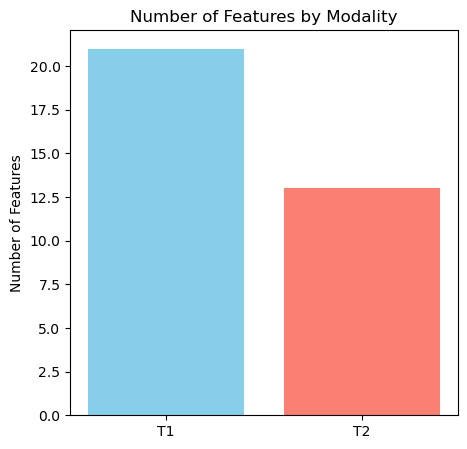

In [77]:
# Data
modalities = list(modality_counts.keys())
counts = list(modality_counts.values())

# Bar plot
plt.figure(figsize=(5, 5))
plt.bar(modalities, counts, color=['skyblue', 'salmon'])
plt.ylabel('Number of Features')
plt.title('Number of Features by Modality')
plt.show()

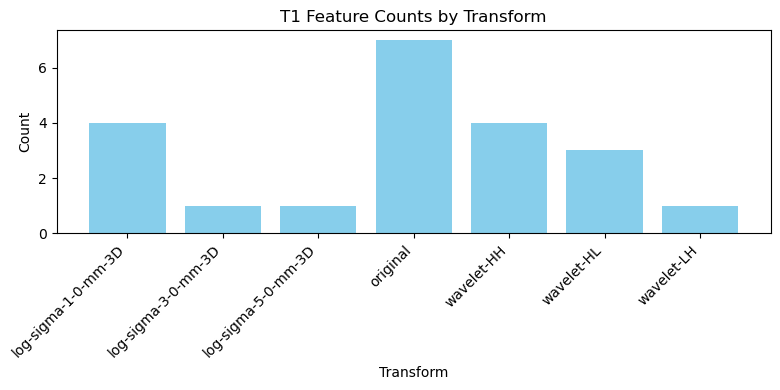

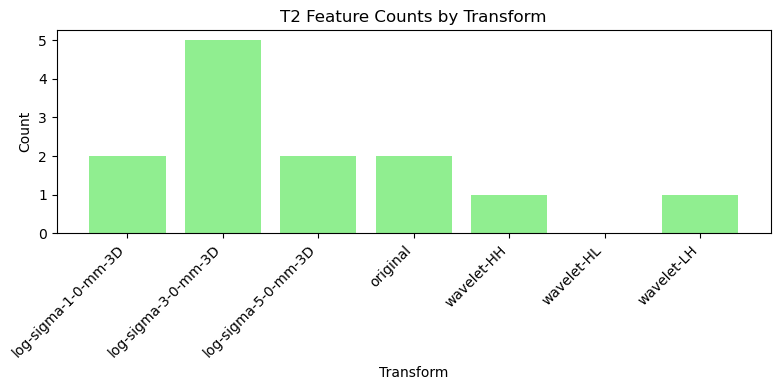

In [78]:
# Get all transforms in a fixed order
all_transforms = sorted({transform for (_, transform) in modality_transform_counts.keys()})

# Separate T1 and T2
t1_counts = {transform: modality_transform_counts.get(('T1', transform), 0) for transform in all_transforms}
t2_counts = {transform: modality_transform_counts.get(('T2', transform), 0) for transform in all_transforms}

# Plot T1
plt.figure(figsize=(8,4))
plt.bar(t1_counts.keys(), t1_counts.values(), color='skyblue')
plt.title('T1 Feature Counts by Transform')
plt.ylabel('Count')
plt.xlabel('Transform')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot T2
plt.figure(figsize=(8,4))
plt.bar(t2_counts.keys(), t2_counts.values(), color='lightgreen')
plt.title('T2 Feature Counts by Transform')
plt.ylabel('Count')
plt.xlabel('Transform')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

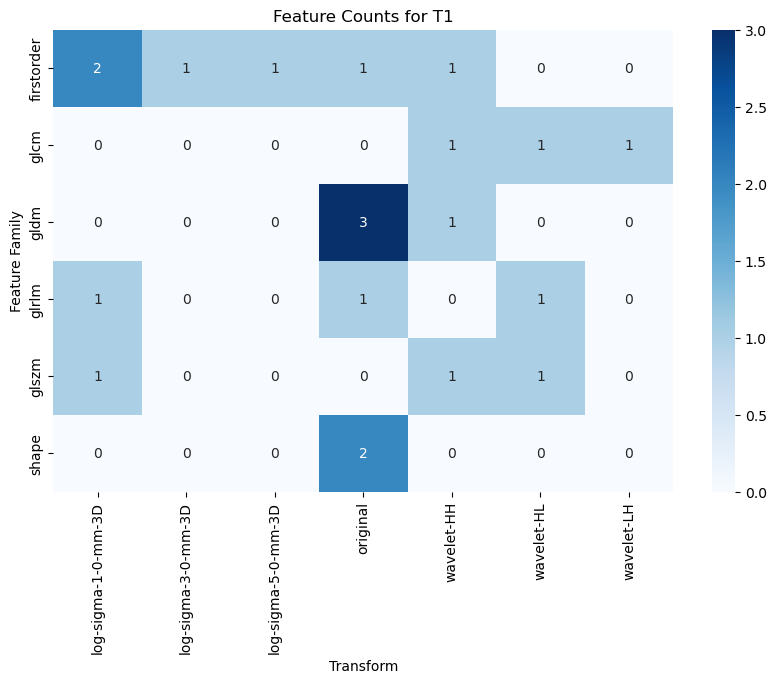

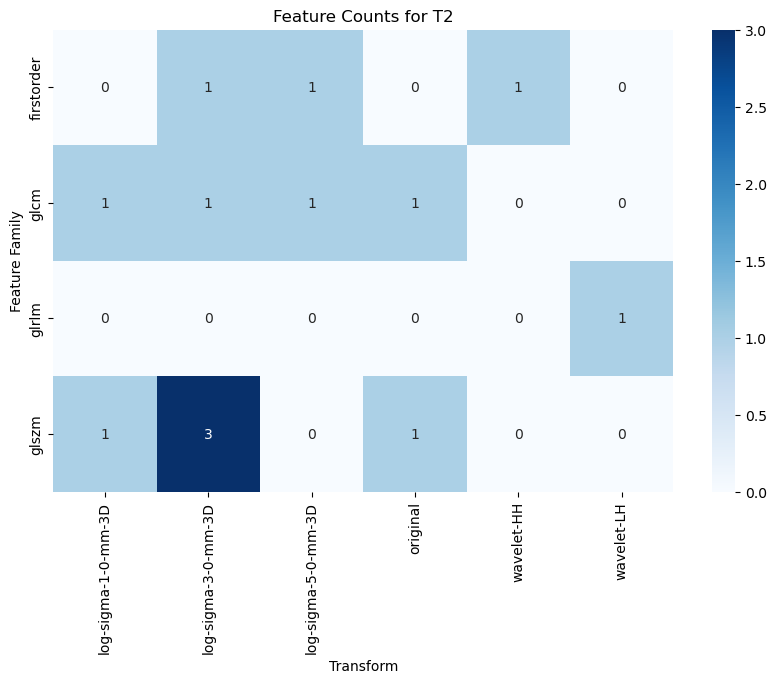

In [79]:
# Convert Counter to a DataFrame
data = []
for (modality, transform, family), count in modality_transform_family_counts.items():
    data.append({'modality': modality, 'transform': transform, 'feature_family': family, 'count': count})

df = pd.DataFrame(data)

# Plot one heatmap per modality
modalities = df['modality'].unique()

for mod in modalities:
    mod_data = df[df['modality'] == mod]
    heatmap_data = mod_data.pivot(index='feature_family', columns='transform', values='count').fillna(0)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Feature Counts for {mod}')
    plt.ylabel('Feature Family')
    plt.xlabel('Transform')
    plt.show()